In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv("/content/OnlineRetail.csv", encoding="latin1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200594 entries, 0 to 200593
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    200594 non-null  object 
 1   StockCode    200594 non-null  object 
 2   Description  199802 non-null  object 
 3   Quantity     200594 non-null  int64  
 4   InvoiceDate  200594 non-null  object 
 5   UnitPrice    200593 non-null  float64
 6   CustomerID   142574 non-null  float64
 7   Country      200593 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 12.2+ MB


,0
InvoiceNo,0
StockCode,0
Description,792
Quantity,0
InvoiceDate,0
UnitPrice,1
CustomerID,58020
Country,1


In [ ]:
df = df.dropna(subset=['CustomerID'])#Remove Missing Customer ID
df = df.drop_duplicates()#Remove Duplicates
df = df[df['Quantity'] > 0]#Remove Negative Quantities
df = df[df['UnitPrice'] > 0]#Remove Negative Prices



In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 137503 entries, 0 to 200592
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    137503 non-null  object        
 1   StockCode    137503 non-null  object        
 2   Description  137503 non-null  object        
 3   Quantity     137503 non-null  int64         
 4   InvoiceDate  137503 non-null  datetime64[ns]
 5   UnitPrice    137503 non-null  float64       
 6   CustomerID   137503 non-null  float64       
 7   Country      137503 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 9.4+ MB


In [ ]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
df['Year'] = df['InvoiceDate'].dt.year

df['Month'] = df['InvoiceDate'].dt.month

df['Day'] = df['InvoiceDate'].dt.day

df['Weekday'] = df['InvoiceDate'].dt.day_name()

In [ ]:
monthly_revenue = (
    df.groupby('Month')['Revenue']
    .sum()
    .reset_index()
)

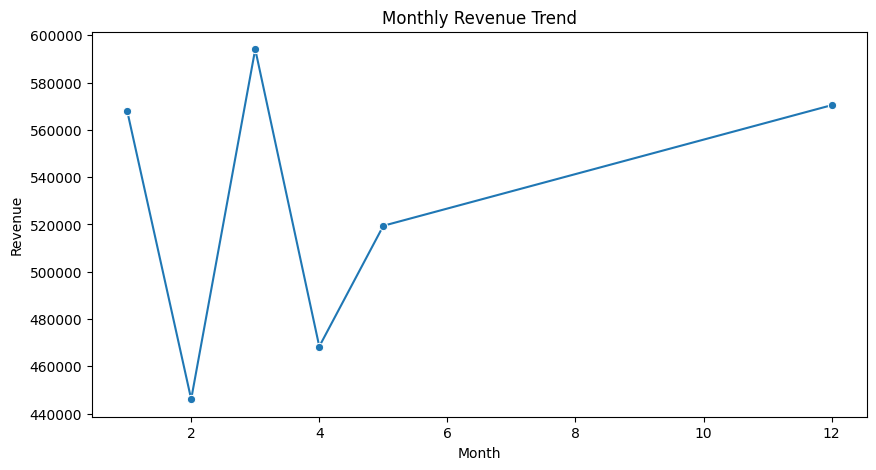

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_revenue,
    x='Month',
    y='Revenue',
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.show()

In [ ]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

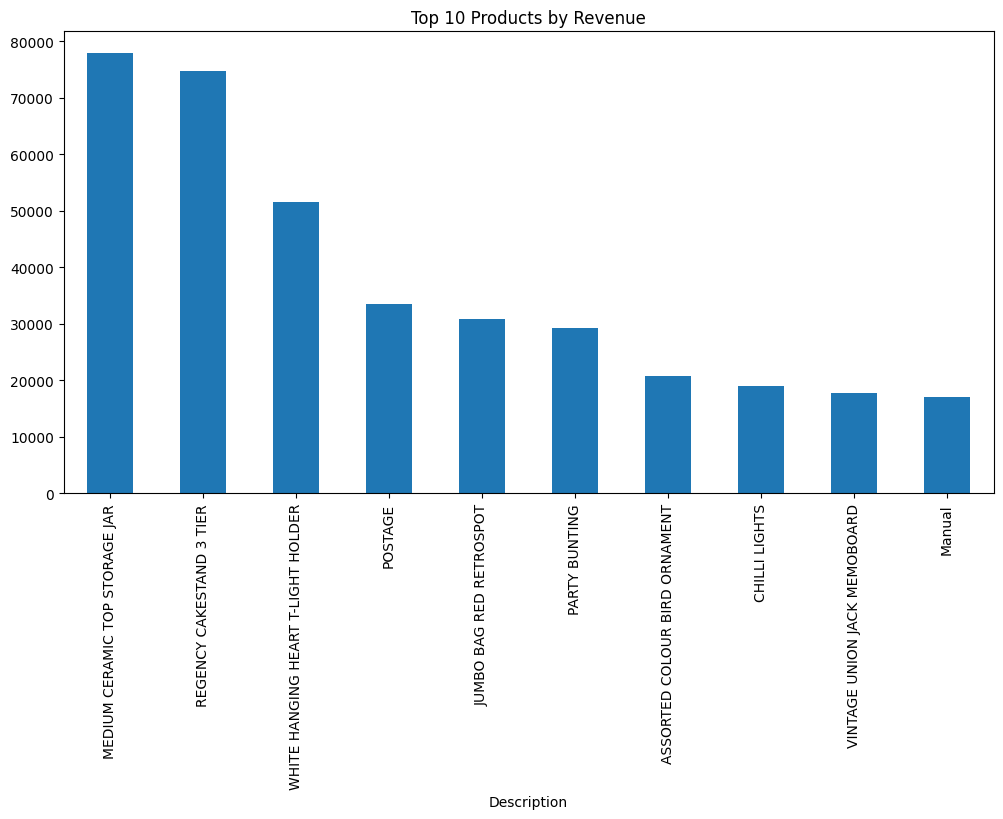

In [ ]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title('Top 10 Products by Revenue')

plt.show()

In [ ]:
top_countries = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

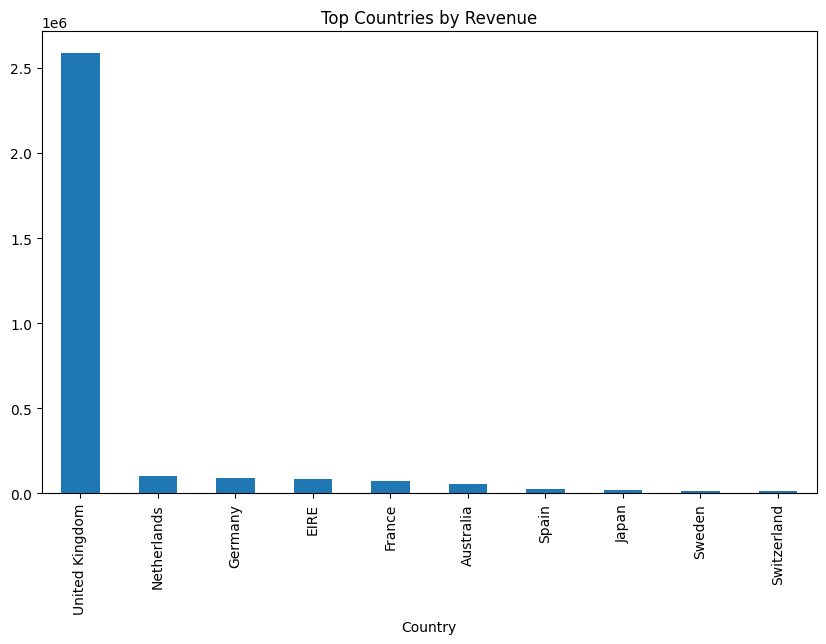

In [ ]:
plt.figure(figsize=(10,6))

top_countries.plot(kind='bar')

plt.title('Top Countries by Revenue')

plt.show()

In [ ]:
df.to_csv(
    "cleaned_retail_data.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download(
    "cleaned_retail_data.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df.shape)

(137503, 13)


In [ ]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Day',
       'Weekday'],
      dtype='object')


In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Day,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday


In [ ]:
# Create daily sales dataset

daily_sales = (
    df.groupby(df['InvoiceDate'].dt.date)['Quantity']
    .sum()
    .reset_index()
)

daily_sales.columns = ['Date', 'Quantity']

daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

daily_sales = daily_sales.sort_values('Date')

# Time features

daily_sales['Month'] = daily_sales['Date'].dt.month
daily_sales['DayOfWeek'] = daily_sales['Date'].dt.dayofweek
daily_sales['Quarter'] = daily_sales['Date'].dt.quarter

# Lag features

daily_sales['Lag_1'] = daily_sales['Quantity'].shift(1)
daily_sales['Lag_7'] = daily_sales['Quantity'].shift(7)

# Rolling features

daily_sales['Rolling_7'] = (
    daily_sales['Quantity']
    .rolling(7)
    .mean()
)

daily_sales['Rolling_30'] = (
    daily_sales['Quantity']
    .rolling(30)
    .mean()
)

# Remove nulls

daily_sales = daily_sales.dropna()

daily_sales.head()

,Date,Quantity,Month,DayOfWeek,Quarter,Lag_1,Lag_7,Rolling_7,Rolling_30
29,2011-01-14,21098,1,4,1,8309.0,21534.0,13712.714286,15129.666667
30,2011-01-16,4086,1,6,1,21098.0,15122.0,12136.142857,14462.066667
31,2011-01-17,8692,1,0,1,4086.0,8125.0,12217.142857,13715.900000
32,2011-01-18,80605,1,1,1,8692.0,9380.0,22392.142857,16009.466667
33,2011-01-19,15869,1,2,1,80605.0,26072.0,20934.571429,15997.066667


In [ ]:
daily_sales.shape

(106, 9)

In [ ]:
X = daily_sales[
    [
        'Month',
        'DayOfWeek',
        'Quarter',
        'Lag_1',
        'Lag_7',
        'Rolling_7',
        'Rolling_30'
    ]
]

y = daily_sales['Quantity']

In [ ]:
split_index = int(len(daily_sales) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
print("Linear Regression")

print("MAE:",
      mean_absolute_error(y_test, lr_pred))

print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test,
              lr_pred
          )
      ))

print("R2:",
      r2_score(
          y_test,
          lr_pred
      ))

Linear Regression
MAE: 7381.832476651058
RMSE: 9030.31217117772
R2: -0.6695848208551247


In [ ]:
print("Random Forest")

print("MAE:",
      mean_absolute_error(
          y_test,
          rf_pred
      ))

print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test,
              rf_pred
          )
      ))

print("R2:",
      r2_score(
          y_test,
          rf_pred
      ))

Random Forest
MAE: 4078.2302272727275
RMSE: 6223.5769287961975
R2: 0.20698192824692152


In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance)

      Feature  Importance
5   Rolling_7    0.401027
6  Rolling_30    0.273749
1   DayOfWeek    0.218711
4       Lag_7    0.054601
3       Lag_1    0.037357
0       Month    0.012039
2     Quarter    0.002516


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("XGBoost")

print("MAE:",
      mean_absolute_error(y_test, xgb_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, xgb_pred)))

print("R2:",
      r2_score(y_test, xgb_pred))

XGBoost
MAE: 4153.97998046875
RMSE: 6125.1834258248955
R2: 0.23185855150222778


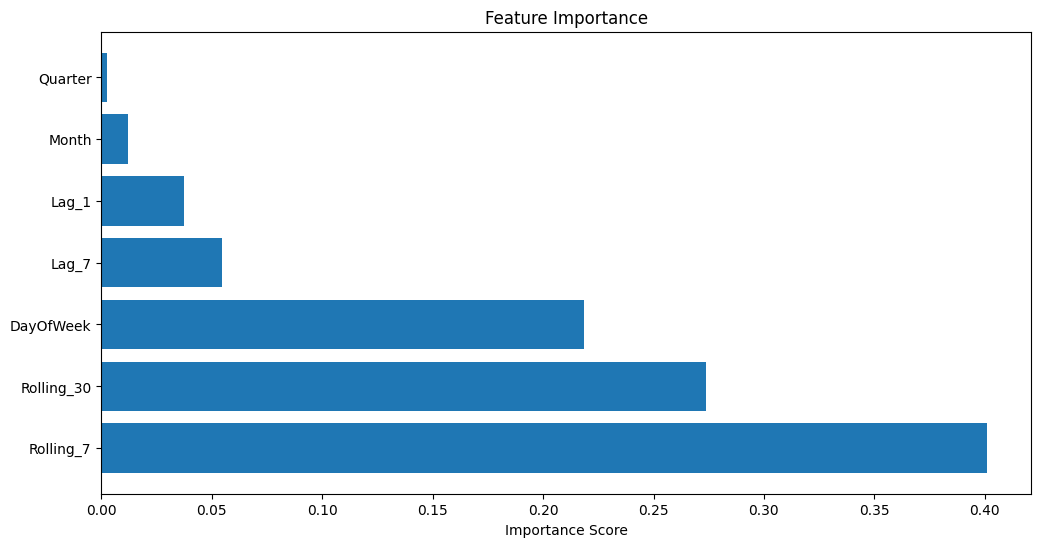

In [ ]:
plt.figure(figsize=(12,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title('Feature Importance')
plt.xlabel('Importance Score')

plt.show()

In [ ]:
top_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top_products

,Quantity
Description,
MEDIUM CERAMIC TOP STORAGE JAR,74796
WORLD WAR 2 GLIDERS ASSTD DESIGNS,27364
WHITE HANGING HEART T-LIGHT HOLDER,19235
PACK OF 72 RETROSPOT CAKE CASES,18249
JUMBO BAG RED RETROSPOT,17331
ASSORTED COLOUR BIRD ORNAMENT,12854
PACK OF 12 LONDON TISSUES,12840
SMALL POPCORN HOLDER,12304
ASSORTED COLOURS SILK FAN,11652


In [ ]:
inventory = pd.DataFrame()

inventory['Product'] = top_products.index
inventory['Historical_Demand'] = top_products.values

In [ ]:
import numpy as np

np.random.seed(42)

inventory['Current_Stock'] = np.random.randint(
    100,
    1000,
    size=len(inventory)
)

In [ ]:
inventory['Forecast_Demand'] = (
    inventory['Historical_Demand'] * 1.10
).astype(int)

In [ ]:
inventory['Lead_Time'] = 7

inventory['Safety_Stock'] = 100

In [ ]:
inventory['Reorder_Point'] = (
    (inventory['Forecast_Demand'] / 30)
    * inventory['Lead_Time']
) + inventory['Safety_Stock']

In [ ]:
inventory['Action'] = np.where(
    inventory['Current_Stock']
    < inventory['Reorder_Point'],
    'Reorder',
    'Sufficient'
)

In [ ]:
inventory.head(20)

,Product,Historical_Demand,Current_Stock,Forecast_Demand,Lead_Time,Safety_Stock,Reorder_Point,Action
0,MEDIUM CERAMIC TOP STORAGE JAR,74796,202,82275,7,100,19297.500000,Reorder
1,WORLD WAR 2 GLIDERS ASSTD DESIGNS,27364,535,30100,7,100,7123.333333,Reorder
2,WHITE HANGING HEART T-LIGHT HOLDER,19235,960,21158,7,100,5036.866667,Reorder
3,PACK OF 72 RETROSPOT CAKE CASES,18249,370,20073,7,100,4783.700000,Reorder
4,JUMBO BAG RED RETROSPOT,17331,206,19064,7,100,4548.266667,Reorder
5,ASSORTED COLOUR BIRD ORNAMENT,12854,171,14139,7,100,3399.100000,Reorder
6,PACK OF 12 LONDON TISSUES,12840,800,14124,7,100,3395.600000,Reorder
7,SMALL POPCORN HOLDER,12304,120,13534,7,100,3257.933333,Reorder
8,ASSORTED COLOURS SILK FAN,11652,714,12817,7,100,3090.633333,Reorder
9,MINI PAINT SET VINTAGE,11341,221,12475,7,100,3010.833333,Reorder


In [ ]:
inventory['Stock_Status'] = np.select(
    [
        inventory['Current_Stock'] < inventory['Reorder_Point'],
        inventory['Current_Stock'] < inventory['Reorder_Point'] * 1.5
    ],
    [
        'Critical',
        'Low'
    ],
    default='Healthy'
)

In [ ]:
inventory.to_csv(
    "inventory_optimization.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download(
    "inventory_optimization.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
inventory['Avg_Daily_Demand'] = (
    inventory['Historical_Demand'] / 276
)

In [ ]:
inventory['Forecast_30_Days'] = (
    inventory['Avg_Daily_Demand'] * 30
).astype(int)

In [ ]:
inventory['Reorder_Point'] = (
    inventory['Avg_Daily_Demand']
    * inventory['Lead_Time']
) + inventory['Safety_Stock']

In [ ]:
inventory['Action'] = np.where(
    inventory['Current_Stock']
    < inventory['Reorder_Point'],
    'Reorder',
    'Sufficient'
)

In [ ]:
inventory['Stock_Status'] = np.select(
    [
        inventory['Current_Stock'] < inventory['Reorder_Point'],
        inventory['Current_Stock'] < inventory['Reorder_Point'] * 1.5
    ],
    [
        'Critical',
        'Low'
    ],
    default='Healthy'
)

In [ ]:
inventory[['Product',
           'Current_Stock',
           'Reorder_Point',
           'Action',
           'Stock_Status']].head(10)

,Product,Current_Stock,Reorder_Point,Action,Stock_Status
0,MEDIUM CERAMIC TOP STORAGE JAR,202,1997.000000,Reorder,Critical
1,WORLD WAR 2 GLIDERS ASSTD DESIGNS,535,794.014493,Reorder,Critical
2,WHITE HANGING HEART T-LIGHT HOLDER,960,587.844203,Sufficient,Healthy
3,PACK OF 72 RETROSPOT CAKE CASES,370,562.836957,Reorder,Critical
4,JUMBO BAG RED RETROSPOT,206,539.554348,Reorder,Critical
5,ASSORTED COLOUR BIRD ORNAMENT,171,426.007246,Reorder,Critical
6,PACK OF 12 LONDON TISSUES,800,425.652174,Sufficient,Healthy
7,SMALL POPCORN HOLDER,120,412.057971,Reorder,Critical
8,ASSORTED COLOURS SILK FAN,714,395.521739,Sufficient,Healthy
9,MINI PAINT SET VINTAGE,221,387.634058,Reorder,Critical


In [ ]:
inventory['Action'].value_counts()

,count
Action,
Reorder,11
Sufficient,9


In [ ]:
inventory.to_csv(
    "inventory_optimization.csv",
    index=False
)

daily_sales.to_csv(
    "forecasting_data.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download("inventory_optimization.csv")
files.download("forecasting_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
forecast_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': lr_pred
})

forecast_results.to_csv(
    "forecast_results.csv",
    index=False
)

In [ ]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [ ]:
from google.colab import files
files.download("feature_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>